# K-Means Clustering — Member (RFM)

Clustering khusus untuk **Member** menggunakan fitur **RFM (Recency, Frequency, Monetary)**.


## Import Library

In [1]:
from pathlib import Path
Path('data').mkdir(exist_ok=True)
Path('models').mkdir(exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import json
import joblib

from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, QuantileTransformer
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from hdbscan import HDBSCAN

import warnings
warnings.filterwarnings('ignore')

print('Library imported successfully.')

Library imported successfully.


## Load Data

Menggunakan `df_rfm-Member.parquet` yang sudah berisi Recency, Frequency, Monetary untuk setiap member (user_id).

In [3]:
gc.collect()

rfm = pd.read_parquet('data/df_rfm-member.parquet')
gc.collect()

print(f'RFM table shape: {rfm.shape}')
print(f'Total members: {rfm["user_id"].nunique():,}')
print(rfm.head())

RFM table shape: (2196257, 8)
Total members: 2,196,257
   user_id  Recency  Frequency     Monetary is_repeat_customer  \
0        1      141         34  1070.475000    Repeat Customer   
1        2       12         40  1215.990002    Repeat Customer   
2        3       86         33  1087.569998    Repeat Customer   
3        4      130         25   778.500000    Repeat Customer   
4        5      205         40  1322.699999    Repeat Customer   

   RFM_Scaled_Recency  RFM_Scaled_Frequency  RFM_Scaled_Monetary  
0            0.787411             11.012894            10.652255  
1           -1.078331             13.167335            12.254571  
2           -0.008060             10.653820            10.840494  
3            0.628317              7.781232             7.437218  
4            1.713051             13.167335            13.429591  


## df_cluster: Kolom RFM untuk Clustering

Ambil hanya kolom numerik RFM (Recency, Frequency, Monetary) untuk clustering.

In [4]:
gc.collect()
df_cluster = rfm[['Recency', 'Frequency', 'Monetary']].copy()
gc.collect()

print(f'df_cluster shape: {df_cluster.shape}')
print(df_cluster.describe().round(3))

df_cluster shape: (2196257, 3)
           Recency    Frequency     Monetary
count  2196257.000  2196257.000  2196257.000
mean        86.557        3.330      103.086
std         69.141        2.785       90.815
min          1.000        1.000        0.000
25%         31.000        1.000       39.000
50%         70.000        2.000       75.000
75%        127.000        4.000      138.000
max        522.000       40.000     1348.420


# Step 2: Feature Transformations Pipeline

Menguji 7 metode scaling/transformasi untuk mencari kombinasi terbaik:

1. **ZScore** — StandardScaler
2. **Log1p** — Log(1+x)
3. **Log+ZScore** — Log1p lalu StandardScaler
4. **MinMax** — MinMaxScaler [0,1]
5. **YeoJohnson** — PowerTransformer (yeo-johnson)
6. **Quantile** — QuantileTransformer (normal output)
7. **BoxCox** — PowerTransformer (box-cox) — hanya untuk nilai > 0

### . ZScore (StandardScaler)

In [5]:
gc.collect()
scaler_z = StandardScaler()
ZScore = pd.DataFrame(
    scaler_z.fit_transform(df_cluster),
    columns=['Recency', 'Frequency', 'Monetary']
)
print(f'ZScore: {ZScore.shape}')
gc.collect()

ZScore: (2196257, 3)


0

### . Log1p

In [6]:
gc.collect()
Log1p = np.log1p(df_cluster)
print(f'Log1p: {Log1p.shape}')
gc.collect()

Log1p: (2196257, 3)


0

### . Log1p + ZScore

In [7]:
gc.collect()
scaler_lz = StandardScaler()
LogZScore = pd.DataFrame(
    scaler_lz.fit_transform(Log1p),
    columns=['Recency', 'Frequency', 'Monetary']
)
print(f'Log+ZScore: {LogZScore.shape}')
gc.collect()

Log+ZScore: (2196257, 3)


0

### . MinMax

In [8]:
gc.collect()
scaler_mm = MinMaxScaler()
MinMax = pd.DataFrame(
    scaler_mm.fit_transform(df_cluster),
    columns=['Recency', 'Frequency', 'Monetary']
)
print(f'MinMax: {MinMax.shape}')
gc.collect()

MinMax: (2196257, 3)


0

### . Yeo-Johnson

In [9]:
gc.collect()
scaler_yj = PowerTransformer(method='yeo-johnson', standardize=True)
YeoJohnson = pd.DataFrame(
    scaler_yj.fit_transform(df_cluster),
    columns=['Recency', 'Frequency', 'Monetary']
)
print(f'YeoJohnson: {YeoJohnson.shape}')
gc.collect()

YeoJohnson: (2196257, 3)


0

### . QuantileTransformer

In [10]:
gc.collect()
scaler_qt = QuantileTransformer(output_distribution='normal', random_state=42)
Quantile = pd.DataFrame(
    scaler_qt.fit_transform(df_cluster),
    columns=['Recency', 'Frequency', 'Monetary']
)
print(f'Quantile: {Quantile.shape}')
gc.collect()

Quantile: (2196257, 3)


0

### . Box-Cox (positive values only)

In [11]:
gc.collect()
# Filter hanya baris dengan nilai > 0 untuk Box-Cox
mask_positive = (
    (df_cluster['Recency'] > 0) &
    (df_cluster['Frequency'] > 0) &
    (df_cluster['Monetary'] > 0)
)
df_cluster_clean = df_cluster[mask_positive].copy()
gc.collect()

scaler_bc = PowerTransformer(method='box-cox', standardize=True)
BoxCox = pd.DataFrame(
    scaler_bc.fit_transform(df_cluster_clean),
    columns=['Recency', 'Frequency', 'Monetary']
)
print(f'BoxCox: {BoxCox.shape} (from {df_cluster_clean.shape[0]:,} positive rows)')
gc.collect()

BoxCox: (2196211, 3) (from 2,196,211 positive rows)


0

# Step 3: Metric Evaluation

Evaluasi setiap transformasi dengan **Silhouette Score** dan **Davies-Bouldin Index** pada K=4.
Menggunakan sample 1% untuk evaluasi; model final di-fit pada FULL data dengan Mini-Batch KMeans.

In [12]:
sample_fraction = 0.01
random_state = 42
gc.collect()

transform_dict = {
    'ZScore': ZScore,
    'Log1p': Log1p,
    'Log+ZScore': LogZScore,
    'MinMax': MinMax,
    'YeoJohnson': YeoJohnson,
    'Quantile': Quantile,
    'BoxCox': BoxCox
}

# Sample each transformation
sampled = {}
gc.collect()
for name, df_trans in transform_dict.items():
    sampled[name] = df_trans.sample(
        frac=sample_fraction,
        replace=False,
        random_state=random_state
    )
    print(f'Sampled {name}: {len(sampled[name]):,} rows')

gc.collect()
print('\nRandom sampling complete (1% SRS WOR).')

Sampled ZScore: 21,963 rows
Sampled Log1p: 21,963 rows
Sampled Log+ZScore: 21,963 rows
Sampled MinMax: 21,963 rows
Sampled YeoJohnson: 21,963 rows
Sampled Quantile: 21,963 rows
Sampled BoxCox: 21,962 rows

Random sampling complete (1% SRS WOR).


### Evaluasi K-Means K=4 pada Setiap Transformasi

In [13]:
results = []
optimal_k = 4
gc.collect()

for name, df_sampled in sampled.items():
    kmeans = MiniBatchKMeans(n_clusters=optimal_k, random_state=42, n_init=5, batch_size=4096)
    labels = kmeans.fit_predict(df_sampled)

    sil = silhouette_score(df_sampled, labels)
    dbi = davies_bouldin_score(df_sampled, labels)

    results.append({
        'Transform': name,
        'Silhouette': sil,
        'DBI': dbi
    })
    print(f'{name:12s} | Silhouette: {sil:.4f} | DBI: {dbi:.4f}')

gc.collect()
df_results = pd.DataFrame(results)
print('\n=== Comparison Table ===')
print(df_results.to_string(index=False))

ZScore       | Silhouette: 0.4052 | DBI: 0.8540
Log1p        | Silhouette: 0.3026 | DBI: 1.0205
Log+ZScore   | Silhouette: 0.3064 | DBI: 1.1276
MinMax       | Silhouette: 0.3975 | DBI: 0.8341
YeoJohnson   | Silhouette: 0.3113 | DBI: 1.0994
Quantile     | Silhouette: 0.4559 | DBI: 0.8015
BoxCox       | Silhouette: 0.3215 | DBI: 1.0055

=== Comparison Table ===
 Transform  Silhouette      DBI
    ZScore    0.405162 0.854048
     Log1p    0.302626 1.020533
Log+ZScore    0.306400 1.127603
    MinMax    0.397496 0.834132
YeoJohnson    0.311346 1.099431
  Quantile    0.455913 0.801545
    BoxCox    0.321495 1.005468


### Dual-Axis Visualization: Perbandingan Metrik Antar Transformasi

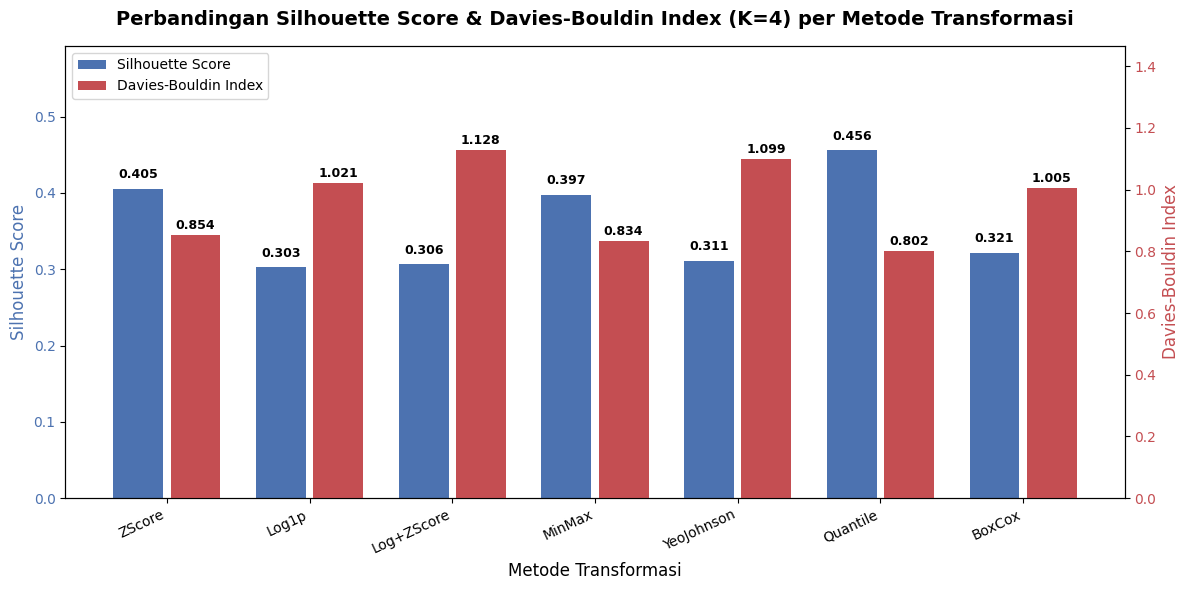

Best transform by Silhouette: Quantile
Best transform by DBI:        Quantile


In [14]:
fig, ax1 = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(df_results))

bars1 = ax1.bar(x_pos - 0.2, df_results['Silhouette'], width=0.35, color='#4C72B0', label='Silhouette Score')
ax1.set_ylabel('Silhouette Score', color='#4C72B0', fontsize=12)
ax1.set_ylim(0, max(df_results['Silhouette']) * 1.3)
ax1.tick_params(axis='y', labelcolor='#4C72B0')

ax2 = ax1.twinx()
bars2 = ax2.bar(x_pos + 0.2, df_results['DBI'], width=0.35, color='#C44E52', label='Davies-Bouldin Index')
ax2.set_ylabel('Davies-Bouldin Index', color='#C44E52', fontsize=12)
ax2.set_ylim(0, max(df_results['DBI']) * 1.3)
ax2.tick_params(axis='y', labelcolor='#C44E52')

ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_results['Transform'], rotation=25, ha='right', fontsize=10)
ax1.set_xlabel('Metode Transformasi', fontsize=12)

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Perbandingan Silhouette Score & Davies-Bouldin Index (K=4) per Metode Transformasi',
          fontsize=14, fontweight='bold', pad=15)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4C72B0', label='Silhouette Score'),
                   Patch(facecolor='#C44E52', label='Davies-Bouldin Index')]
ax1.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

best_sil = df_results.loc[df_results['Silhouette'].idxmax(), 'Transform']
best_dbi = df_results.loc[df_results['DBI'].idxmin(), 'Transform']
print(f'Best transform by Silhouette: {best_sil}')
print(f'Best transform by DBI:        {best_dbi}')

### Multi-K Silhouette/DBI pada Transformasi Terbaik

Menentukan jumlah cluster (K) optimal berdasarkan Silhouette Score dan DBI.

Using best transform: Quantile
=== Data Evaluasi Metrik ===
 k Silhouette Score Davies-Bouldin Index
 2           0.7161               0.3999
 3           0.4266               0.9860
 4           0.4559               0.8015
 5           0.3390               0.9706
 6           0.4272               0.8027
 7           0.3028               1.0229
 8           0.3242               0.9365
 9           0.3053               0.9549
10           0.3133               0.8916


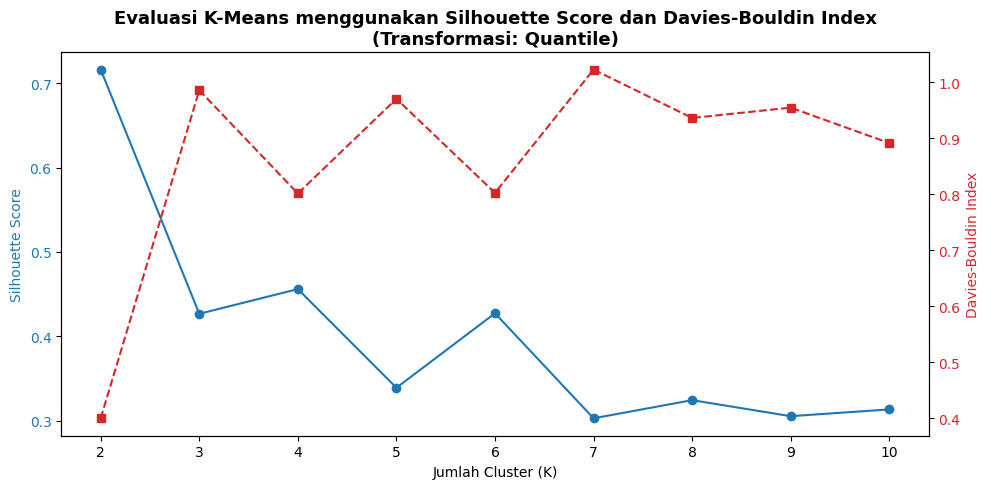


K optimal berdasarkan Silhouette Score tertinggi: K=2


In [15]:
best_transform_name = df_results.loc[df_results['Silhouette'].idxmax(), 'Transform']
print(f'Using best transform: {best_transform_name}')

best_df_sampled = sampled[best_transform_name]

silhouette_scores = []
dbi_scores = []
gc.collect()
K_eval_range = range(2, 11)

for k in K_eval_range:
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=5, batch_size=4096)
    labels = kmeans.fit_predict(best_df_sampled)

    sil_thresh = silhouette_score(best_df_sampled, labels)
    silhouette_scores.append(sil_thresh)

    dbi_thresh = davies_bouldin_score(best_df_sampled, labels)
    dbi_scores.append(dbi_thresh)

gc.collect()

df_metrics = pd.DataFrame({
    'k': list(K_eval_range),
    'Silhouette Score': silhouette_scores,
    'Davies-Bouldin Index': dbi_scores
})

print('=== Data Evaluasi Metrik ===')
print(df_metrics.to_string(index=False, formatters={
    'Silhouette Score': '{:.4f}'.format,
    'Davies-Bouldin Index': '{:.4f}'.format
}))

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Jumlah Cluster (K)')
ax1.set_ylabel('Silhouette Score', color=color)
ax1.plot(K_eval_range, silhouette_scores, marker='o', linestyle='-', color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Davies-Bouldin Index', color=color)
ax2.plot(K_eval_range, dbi_scores, marker='s', linestyle='--', color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title(f'Evaluasi K-Means menggunakan Silhouette Score dan Davies-Bouldin Index\n(Transformasi: {best_transform_name})', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()

# Pilih K optimal (berdasarkan Silhouette tertinggi)
optimal_k = df_metrics.loc[df_metrics['Silhouette Score'].idxmax(), 'k']
print(f'\nK optimal berdasarkan Silhouette Score tertinggi: K={int(optimal_k)}')

# Step 4: Final Model — Mini-Batch KMeans pada FULL Data

Menggunakan **Mini-Batch KMeans** untuk melatih seluruh data member (~2.2M baris) dan bukan hanya sample.

In [16]:
optimal_k = int(optimal_k)

# Dapatkan scaler/transform terbaik
scaler_map = {
    'ZScore': scaler_z,
    'Log1p': None,  # Log1p tidak perlu scaler khusus (cuma np.log1p)
    'Log+ZScore': scaler_lz,
    'MinMax': scaler_mm,
    'YeoJohnson': scaler_yj,
    'Quantile': scaler_qt,
    'BoxCox': scaler_bc
}

if best_transform_name == 'BoxCox':
    X_final = df_cluster_clean.copy()
    best_scaler = scaler_bc
elif best_transform_name == 'Log1p':
    X_final = np.log1p(df_cluster)
    best_scaler = None
else:
    X_final = df_cluster.copy()
    best_scaler = scaler_map[best_transform_name]
    if best_scaler is not None:
        X_final = pd.DataFrame(
            best_scaler.transform(X_final),
            columns=['Recency', 'Frequency', 'Monetary']
        )

print(f'X_final shape for training: {X_final.shape}')
gc.collect()

X_final shape for training: (2196257, 3)


50

In [17]:
# Train Mini-Batch KMeans pada FULL data
print(f'Training Mini-Batch KMeans dengan K={optimal_k} pada FULL data ({X_final.shape[0]:,} baris)...')
gc.collect()

kmeans_member = MiniBatchKMeans(
    n_clusters=4,
    random_state=42,
    n_init=5,
    batch_size=4096,
    max_iter=100
)

kmeans_member.fit(X_final)
gc.collect()

print(f'Training complete. Inertia: {kmeans_member.inertia_:.2f}')
print(f'N_iter: {kmeans_member.n_iter_}')

Training Mini-Batch KMeans dengan K=2 pada FULL data (2,196,257 baris)...
Training complete. Inertia: 2648665.92
N_iter: 2


In [18]:
# Predict pada FULL data
print('Predicting cluster labels on full data...')
gc.collect()
full_labels = kmeans_member.predict(X_final)
gc.collect()

print(f'Cluster distribution:')
unique, counts = np.unique(full_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c:,} members ({c/len(full_labels)*100:.1f}%)')

Predicting cluster labels on full data...
Cluster distribution:
  Cluster 0: 399,069 members (18.2%)
  Cluster 1: 659,353 members (30.0%)
  Cluster 2: 627,517 members (28.6%)
  Cluster 3: 510,318 members (23.2%)


In [19]:
# Evaluasi Silhouette pada sample (karena silhouette_score O(n^2))
sample_size = min(50000, len(X_final))
sample_idx = np.random.choice(len(X_final), size=sample_size, replace=False)
sil_sample = silhouette_score(X_final.iloc[sample_idx] if hasattr(X_final, 'iloc') else X_final[sample_idx],
                              full_labels[sample_idx])
print(f'Silhouette Score (sample {sample_size:,}): {sil_sample:.4f}')

Silhouette Score (sample 50,000): 0.4556


## PCA 2D Visualization

In [20]:
# Sample untuk visualisasi
viz_sample_idx = np.random.choice(len(X_final), size=min(30000, len(X_final)), replace=False)
X_viz = X_final.iloc[viz_sample_idx] if hasattr(X_final, 'iloc') else X_final[viz_sample_idx]
viz_labels = full_labels[viz_sample_idx]

pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_viz)

explained_variance = pca.explained_variance_ratio_ * 100
print(f'PC1 explains: {explained_variance[0]:.2f}%')
print(f'PC2 explains: {explained_variance[1]:.2f}%')
print(f'Total informasi 3D -> 2D: {sum(explained_variance):.2f}%')

PC1 explains: 83.87%
PC2 explains: 12.70%
Total informasi 3D -> 2D: 96.56%


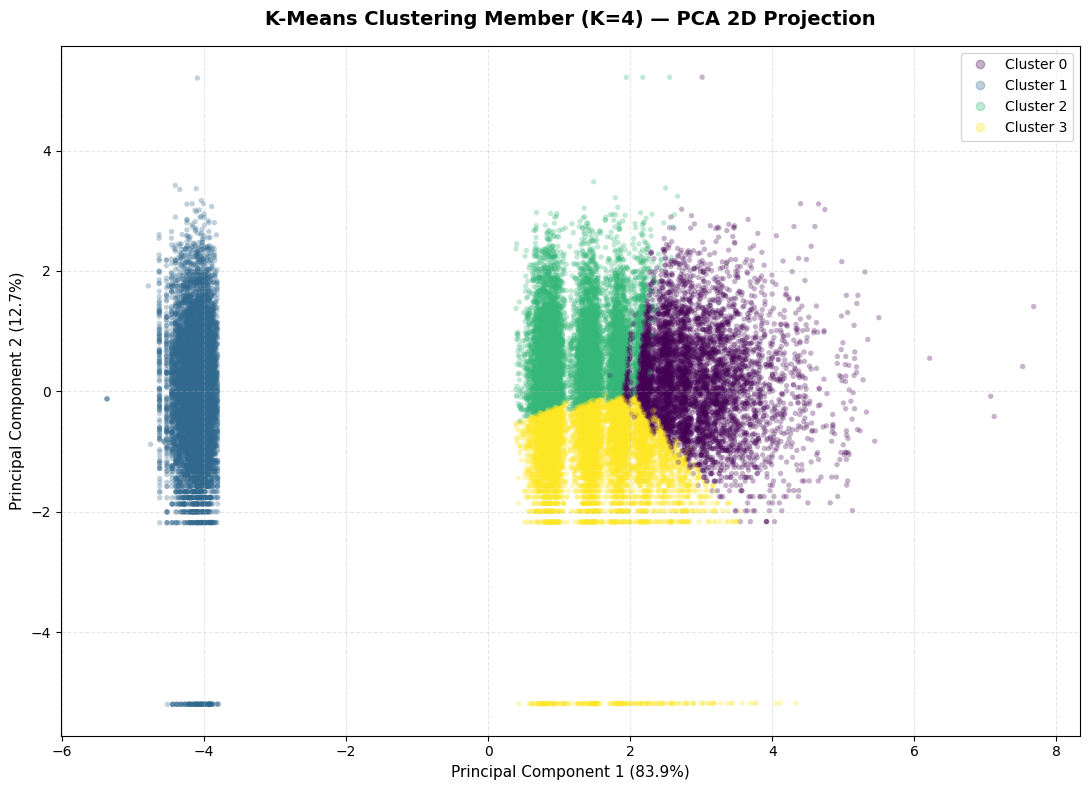

In [21]:
fig, ax = plt.subplots(figsize=(11, 8))

scatter = ax.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=viz_labels,
    cmap='viridis',
    s=15,
    alpha=0.3,
    edgecolors='none'
)

ax.set_xlabel(f'Principal Component 1 ({explained_variance[0]:.1f}%)', fontsize=11)
ax.set_ylabel(f'Principal Component 2 ({explained_variance[1]:.1f}%)', fontsize=11)
plt.title(f'K-Means Clustering Member (K={4}) — PCA 2D Projection', fontsize=14, fontweight='bold', pad=15)

handles, _ = scatter.legend_elements(prop='colors')
legend_labels = [f'Cluster {i}' for i in range(4)]
ax.legend(handles, legend_labels, loc='upper right', frameon=True, facecolor='white')

plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## HDBSCAN Clustering (Alternatif)

In [22]:
clusterer = HDBSCAN(
    min_cluster_size=4100,
    min_samples=40,
    metric='euclidean',
    core_dist_n_jobs=-1,
    prediction_data=True
)

hdb_labels = clusterer.fit_predict(X_viz)
n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise = list(hdb_labels).count(-1)
print(f'HDBSCAN clusters found: {n_clusters}')
print(f'Noise points: {n_noise}')

HDBSCAN clusters found: 4
Noise points: 1252


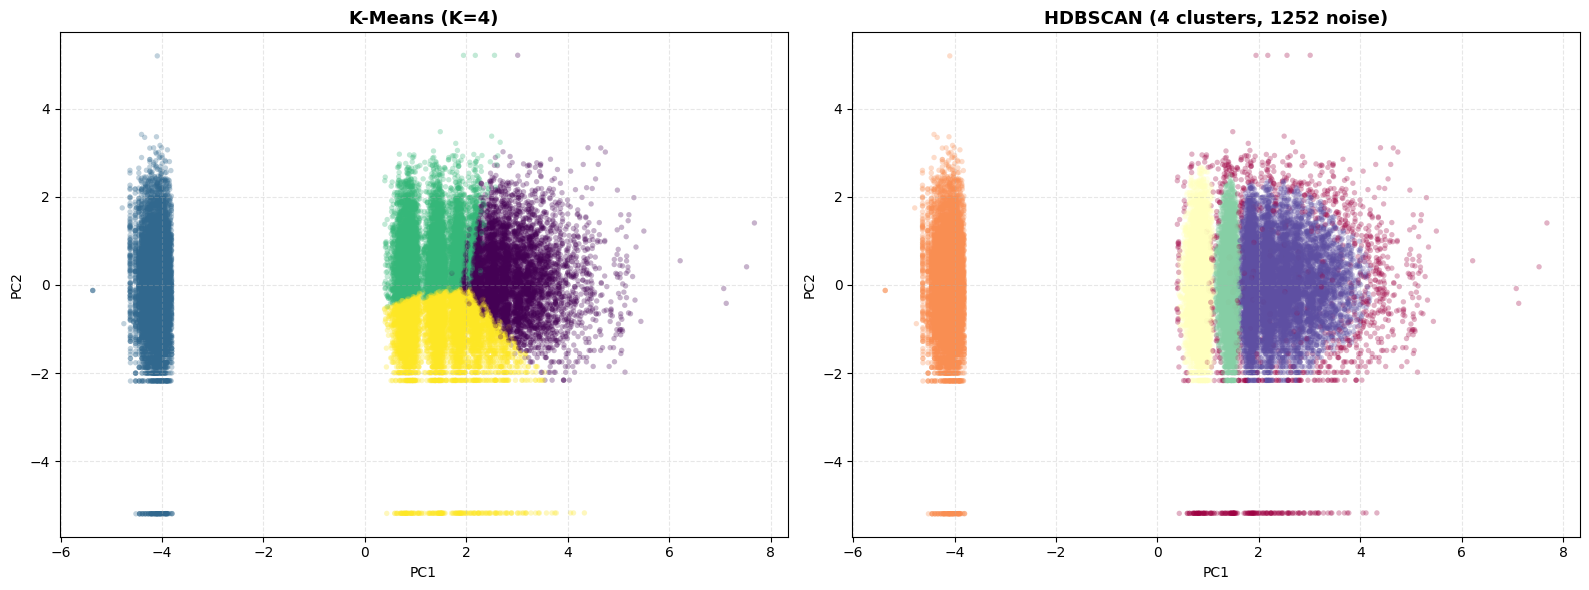

5420

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# K-Means
ax1.scatter(pca_data[:, 0], pca_data[:, 1], c=viz_labels, cmap='viridis', s=15, alpha=0.3, edgecolors='none')
ax1.set_title(f'K-Means (K=4)', fontsize=13, fontweight='bold')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.grid(True, linestyle='--', alpha=0.3)

# HDBSCAN
ax2.scatter(pca_data[:, 0], pca_data[:, 1], c=hdb_labels, cmap='Spectral', s=15, alpha=0.3, edgecolors='none')
ax2.set_title(f'HDBSCAN ({n_clusters} clusters, {n_noise} noise)', fontsize=13, fontweight='bold')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()
gc.collect()

# Step 5: Profiling Segmen & Save Model

Melihat karakteristik setiap cluster member berdasarkan RFM dan menyimpan model untuk integrasi app.

In [24]:
# Attach cluster labels to rfm
rfm_with_cluster = rfm.copy()

if best_transform_name == 'BoxCox':
    rfm_with_cluster = rfm_with_cluster.loc[mask_positive].copy()

rfm_with_cluster['cluster'] = full_labels

cluster_profile = rfm_with_cluster.groupby('cluster').agg(
    count=('user_id', 'count'),
    R_mean=('Recency', 'mean'),
    F_mean=('Frequency', 'mean'),
    M_mean=('Monetary', 'mean'),
    R_median=('Recency', 'median'),
    F_median=('Frequency', 'median'),
    M_median=('Monetary', 'median'),
    monetary_sum=('Monetary', 'sum')
).reset_index()

cluster_profile['pct'] = (cluster_profile['count'] / cluster_profile['count'].sum() * 100).round(2)
cluster_profile['revenue_share_pct'] = (cluster_profile['monetary_sum'] / cluster_profile['monetary_sum'].sum() * 100).round(2)

print('Cluster Profile:')
print(cluster_profile.to_string(index=False))

Cluster Profile:
 cluster  count     R_mean   F_mean     M_mean  R_median  F_median  M_median  monetary_sum    pct  revenue_share_pct
       0 399069  95.734244 7.834730 249.645855      82.0       7.0     224.5  9.962592e+07  18.17              44.00
       1 659353  86.521974 1.000000  31.018970      70.0       1.0      28.5  2.045245e+07  30.02               9.03
       2 627517 131.275291 2.846304  84.563537     117.0       3.0      81.0  5.306506e+07  28.57              23.44
       3 510318  24.438630 3.411224 104.365311      23.0       3.0      96.0  5.325950e+07  23.24              23.52


### Label Segmen Berdasarkan Profil RFM

Memberi nama unik pada setiap cluster berdasarkan karakteristik:
- **Low Recency, High Frequency, High Monetary** → Champions
- **High Recency, Low Frequency, Low Monetary** → Lost / Hibernating
- **Low Recency, Low Frequency, Medium Monetary** → New / Occasional
- **Medium Recency, High Frequency, High Monetary** → At Risk (regulars who haven't visited recently)

In [25]:
# Simple heuristic labeling based on R, F, M means
cluster_labels = {}
for _, row in cluster_profile.iterrows():
    cid = int(row['cluster'])
    r = row['R_mean']
    f = row['F_mean']
    m = row['M_mean']

    if r < cluster_profile['R_mean'].median() and f > cluster_profile['F_mean'].median() and m > cluster_profile['M_mean'].median():
        label = 'Champions'
    elif r > cluster_profile['R_mean'].median() and f < cluster_profile['F_mean'].median() and m < cluster_profile['M_mean'].median():
        label = 'Hibernating'
    elif r < cluster_profile['R_mean'].median() and f < cluster_profile['F_mean'].median():
        label = 'New Occasional'
    else:
        label = 'At Risk Regulars'
    cluster_labels[cid] = label

rfm_with_cluster['segment_name'] = rfm_with_cluster['cluster'].map(cluster_labels)

print('=== Segment Label Assignment ===')
for cid, label in sorted(cluster_labels.items()):
    n = len(rfm_with_cluster[rfm_with_cluster['cluster'] == cid])
    print(f'  Cluster {cid}: {label} ({n:,} members)')

=== Segment Label Assignment ===
  Cluster 0: At Risk Regulars (399,069 members)
  Cluster 1: New Occasional (659,353 members)
  Cluster 2: Hibernating (627,517 members)
  Cluster 3: Champions (510,318 members)


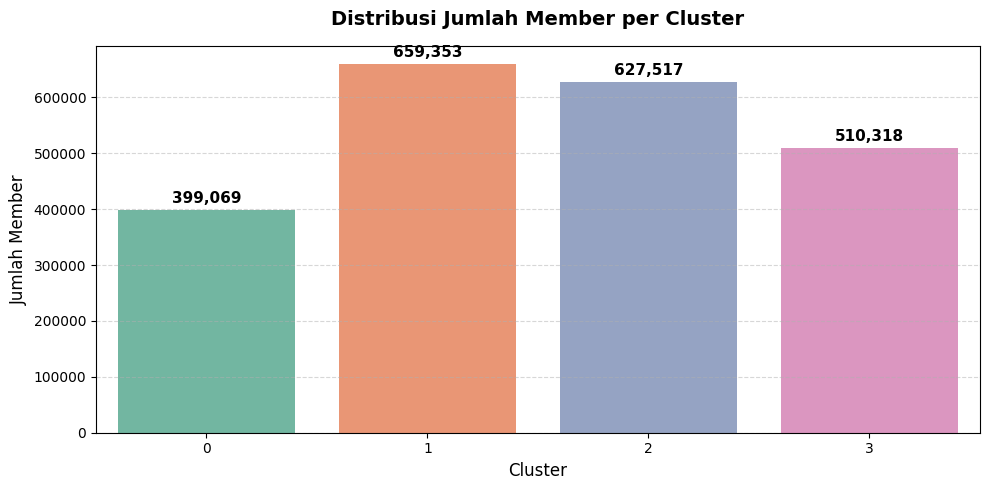

In [26]:
# Visualisasi distribusi segmen
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=cluster_profile,
    x='cluster',
    y='count',
    hue='cluster',
    palette='Set2',
    legend=False
)

for p in ax.patches:
    ax.annotate(
        text=f'{int(p.get_height()):,}',
        xy=(p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='baseline', fontsize=11, fontweight='bold',
        xytext=(0, 5), textcoords='offset points'
    )

plt.title('Distribusi Jumlah Member per Cluster', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Jumlah Member', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [27]:
# Detail profiling per segment
detail_cols = ['cluster', 'count', 'pct', 'revenue_share_pct', 'R_mean', 'F_mean', 'M_mean']
profile_display = cluster_profile[detail_cols].copy()
profile_display['segment_name'] = profile_display['cluster'].map(cluster_labels)
print('=== Cluster Detail Profile ===')
print(profile_display.to_string(index=False))

=== Cluster Detail Profile ===
 cluster  count    pct  revenue_share_pct     R_mean   F_mean     M_mean     segment_name
       0 399069  18.17              44.00  95.734244 7.834730 249.645855 At Risk Regulars
       1 659353  30.02               9.03  86.521974 1.000000  31.018970   New Occasional
       2 627517  28.57              23.44 131.275291 2.846304  84.563537      Hibernating
       3 510318  23.24              23.52  24.438630 3.411224 104.365311        Champions


## Save Model & Data

Menyimpan:
- `model_kmeans_member.joblib` — Mini-Batch KMeans model
- `scaler_member.joblib` — Scaler/transform terbaik (jika ada)
- `member_cluster_metadata.json` — Metadata (cluster labels, feature names, transform info)
- `df_member_with_segments.parquet` — RFM + cluster labels

In [28]:
gc.collect()

# 1. Save KMeans model
joblib.dump(kmeans_member, 'models/model_kmeans_member.joblib')
print('Saved: model_kmeans_member.joblib')

# 2. Save scaler (if not None)
if best_scaler is not None:
    joblib.dump(best_scaler, 'models/scaler_member.joblib')
    print('Saved: scaler_member.joblib')
else:
    print('No scaler to save (used Log1p without scaling)')

gc.collect()

Saved: model_kmeans_member.joblib
Saved: scaler_member.joblib


0

In [29]:
# 3. Save metadata
metadata = {
    'model_type': 'MiniBatchKMeans',
    'k': optimal_k,
    'features': ['Recency', 'Frequency', 'Monetary'],
    'best_transform': best_transform_name,
    'inertia': float(kmeans_member.inertia_),
    'n_iter': int(kmeans_member.n_iter_),
    'silhouette_score': float(sil_sample),
    'total_members': int(rfm_with_cluster.shape[0]),
    'cluster_labels': {int(k): v for k, v in cluster_labels.items()},
    'cluster_profiles': cluster_profile.to_dict('records')
}

with open('models/member_cluster_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print('Saved: member_cluster_metadata.json')

Saved: member_cluster_metadata.json


In [30]:
# 4. Save final data with segments
output_cols = ['user_id', 'Recency', 'Frequency', 'Monetary', 'is_repeat_customer', 'cluster', 'segment_name']
available_cols = [c for c in output_cols if c in rfm_with_cluster.columns]
df_output = rfm_with_cluster[available_cols].copy()
df_output.to_parquet('data/df_member_with_segments.parquet', index=False)
print(f'Saved: df_member_with_segments.parquet ({len(df_output):,} rows)')

Saved: df_member_with_segments.parquet (2,196,257 rows)


In [31]:
gc.collect()
print('=== K-Means Member Clustering Complete ===')
print(f'Total members processed: {rfm_with_cluster.shape[0]:,}')
print(f'Number of clusters (K): {optimal_k}')
print(f'Best transform: {best_transform_name}')
print(f'Silhouette Score: {sil_sample:.4f}')
print('')
print('Output files:')
print('  model_kmeans_member.joblib')
print('  scaler_member.joblib')
print('  member_cluster_metadata.json')
print('  df_member_with_segments.parquet')

=== K-Means Member Clustering Complete ===
Total members processed: 2,196,257
Number of clusters (K): 2
Best transform: Quantile
Silhouette Score: 0.4556

Output files:
  model_kmeans_member.joblib
  scaler_member.joblib
  member_cluster_metadata.json
  df_member_with_segments.parquet
